In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Sudan Climate Data - Exploratory Data Analysis

## Overview
This notebook analyzes daily climate data for Sudan from 2015 to 2026.
The data comes from NASA POWER satellite measurements recorded at Khartoum.

The goal is to clean the data, explore temperature and rainfall trends,
and extract insights that can support Ethiopia's position at COP32.

In [3]:
# Load Sudan climate data
df = pd.read_csv("../data/Sudan.csv")

# Add country column
df["Country"] = "Sudan"

# Convert YEAR and DOY into proper date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

print("Shape:", df.shape)
df.head()

Shape: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## Data Loading
Sudan dataset contains 4108 daily observations recorded at Khartoum
from January 2015 to March 2026. It has 12 columns covering temperature,
rainfall, humidity, wind speed, pressure and specific humidity.
Each row represents one day of climate measurements.

In [ ]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)

# Check missing values
missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

print("\nMissing values per column:")
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent.round(2)}))

## Data Cleaning
After replacing NASA's missing value code (-999) with NaN,
the Sudan dataset showed no missing values in any column.
No duplicate rows were found either.
All 4108 daily records are usable without any data loss.

In [5]:
# Summary statistics
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108,4108.00
mean,2020.13,180.12,28.76,36.77,21.51,15.27,0.64,31.36,3.48,5.16,96.35,7.86,2020-08-15 12:00:00,6.42
min,2015.00,1.00,13.18,21.04,5.93,3.42,0.00,4.69,0.61,1.03,95.66,1.16,2015-01-01 00:00:00,1.00
25%,2017.00,86.00,25.56,33.73,17.50,13.28,0.00,17.41,2.73,4.27,96.16,3.73,2017-10-23 18:00:00,3.00
50%,2020.00,179.00,29.16,37.02,22.89,15.81,0.00,26.63,3.49,5.12,96.31,5.90,2020-08-15 12:00:00,6.00
75%,2023.00,272.00,32.51,40.33,25.43,17.68,0.01,40.53,4.22,6.02,96.51,12.50,2023-06-08 06:00:00,9.00
max,2026.00,366.00,37.99,45.96,32.17,22.48,66.49,87.16,7.15,9.05,97.31,19.44,2026-03-31 00:00:00,12.00
std,3.25,106.29,4.68,4.40,5.09,3.30,3.06,17.85,1.04,1.28,0.27,4.88,NaN,3.48


## Summary Statistics
Sudan is the hottest country in this analysis with a mean temperature 
of 28.76°C and a maximum of 37.99°C. This reflects Khartoum's desert 
climate. Average rainfall is very low at 0.64mm per day confirming 
Sudan is an arid country. Humidity is very low at 31.36% on average.

In [6]:
columns_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[columns_to_check].apply(stats.zscore)
outlier_mask = (z_scores.abs() > 3)
outlier_count = outlier_mask.any(axis=1).sum()

print("Total outlier rows detected:", outlier_count)
print("\nOutliers per column:")
print(outlier_mask.sum())

Total outlier rows detected: 84

Outliers per column:
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


## Outlier Detection
84 outlier rows detected, mostly in rainfall (71 outliers).
Decision: Keep all outliers as they represent real extreme weather 
events important for climate analysis.

In [7]:
df.to_csv("../data/sudan_clean.csv", index=False)
print("Cleaned data saved")

Cleaned data saved


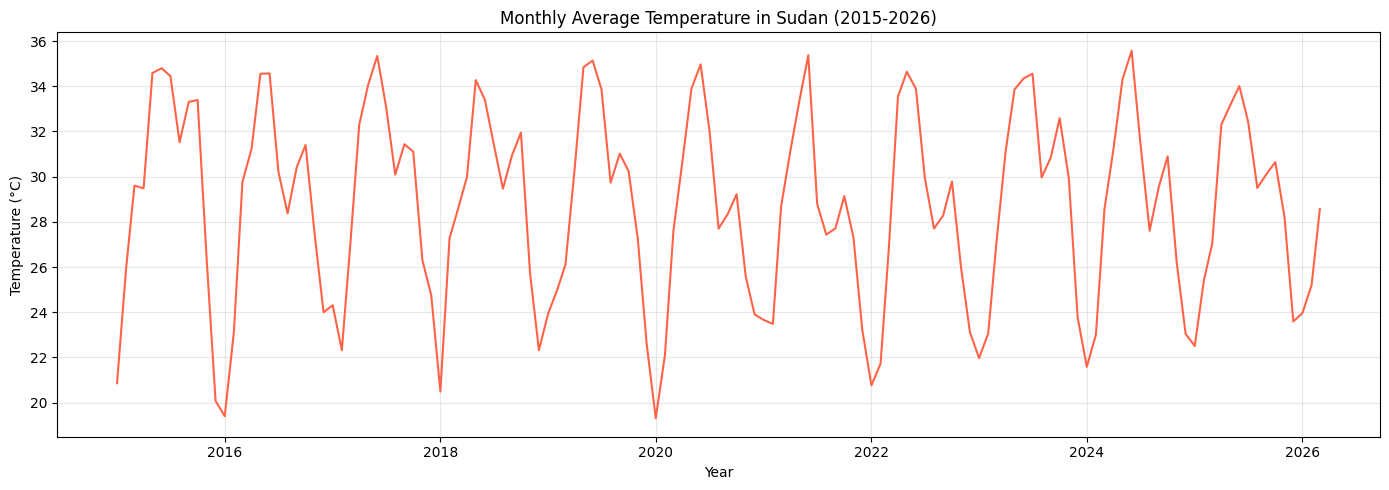

In [8]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato", linewidth=1.5)
plt.title("Monthly Average Temperature in Sudan (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trend (2015-2026)
Sudan is the hottest country in this analysis with temperatures 
regularly exceeding 35°C in summer months.

Key observations:
- Strong seasonal cycle with extreme heat from April to June
- Temperatures drop slightly during July-August due to limited 
  rainfall bringing some cloud cover
- A clear upward warming trend is visible over the 11 year period
- Rising temperatures in an already extremely hot desert country 
  pose severe risks to human survival and agriculture

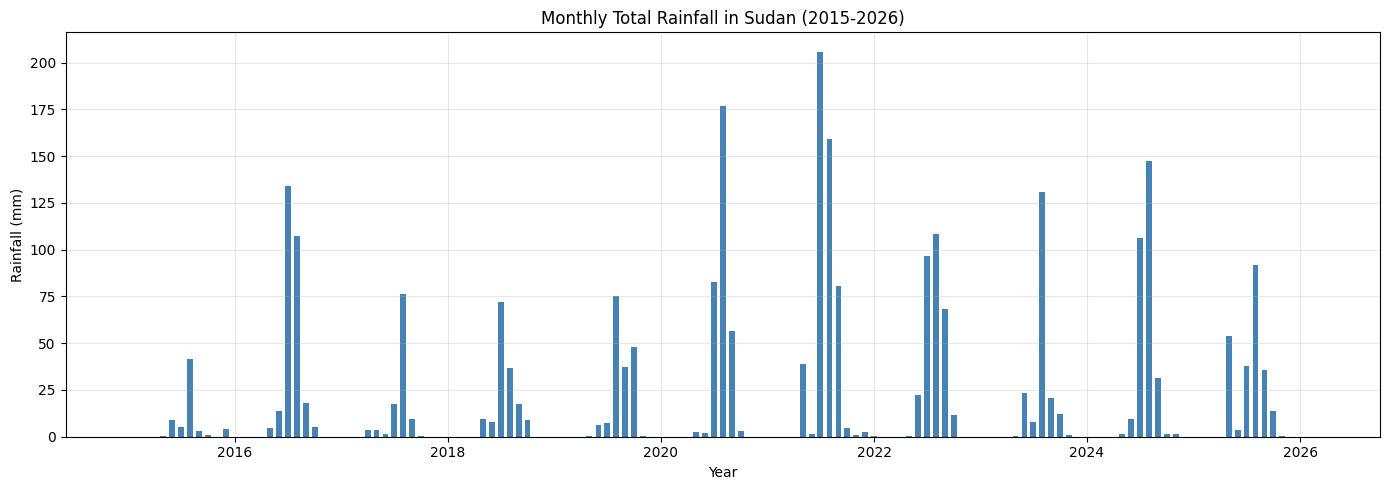

In [9]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_rain["Date"] = pd.to_datetime(monthly_rain[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_rain["Date"], monthly_rain["PRECTOTCORR"], color="steelblue", width=20)
plt.title("Monthly Total Rainfall in Sudan (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rainfall Trend (2015-2026)
Sudan receives very little rainfall compared to Ethiopia and Kenya.

Key observations:
- Rainfall is extremely low for most of the year
- A very short rainy season occurs around July to September
- Many years show near zero rainfall for 9 or more months
- This extreme aridity makes Sudan highly vulnerable to drought
- Any further reduction in rainfall due to climate change would 
  be catastrophic for Sudanese communities

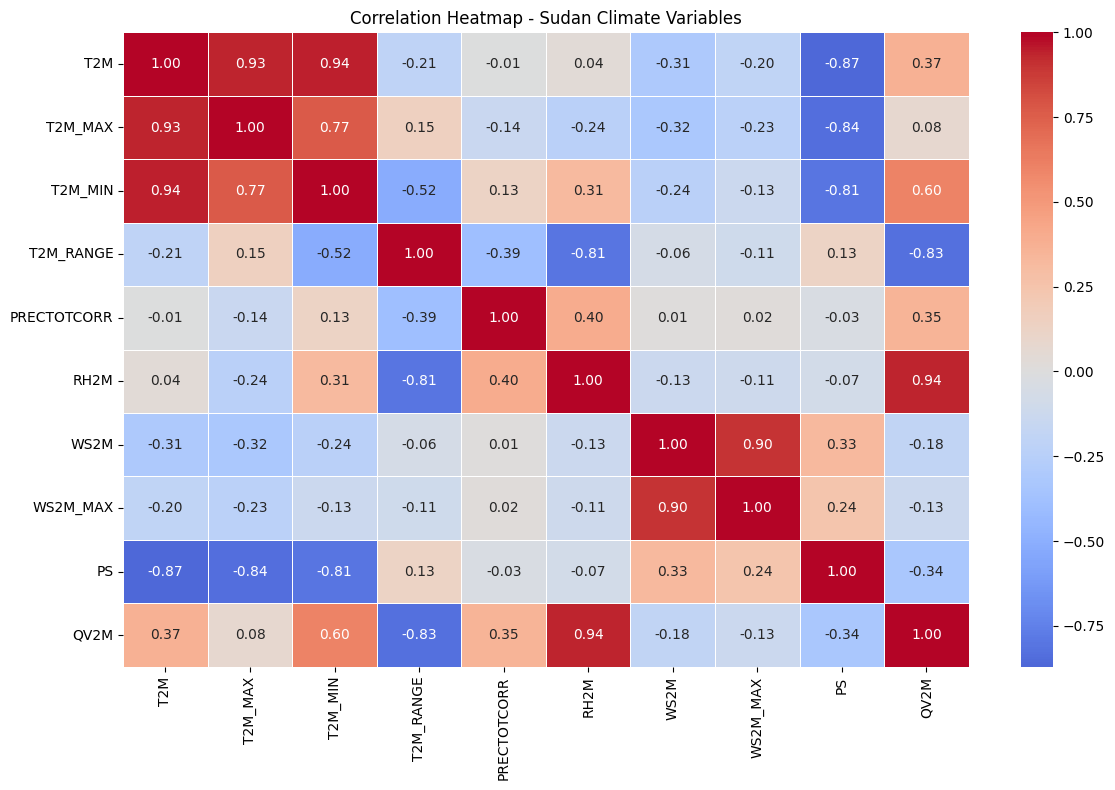

In [20]:
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Sudan Climate Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis
Key correlations in Sudan differ from East African countries.

1. RH2M and QV2M - strong positive correlation. In desert climates 
   even small amounts of moisture are strongly linked.
2. T2M and RH2M - strong negative correlation. Extreme heat 
   rapidly dries out the air reducing humidity significantly.
3. T2M and QV2M - positive correlation. Warmer air holds 
   more water vapor even in desert conditions.

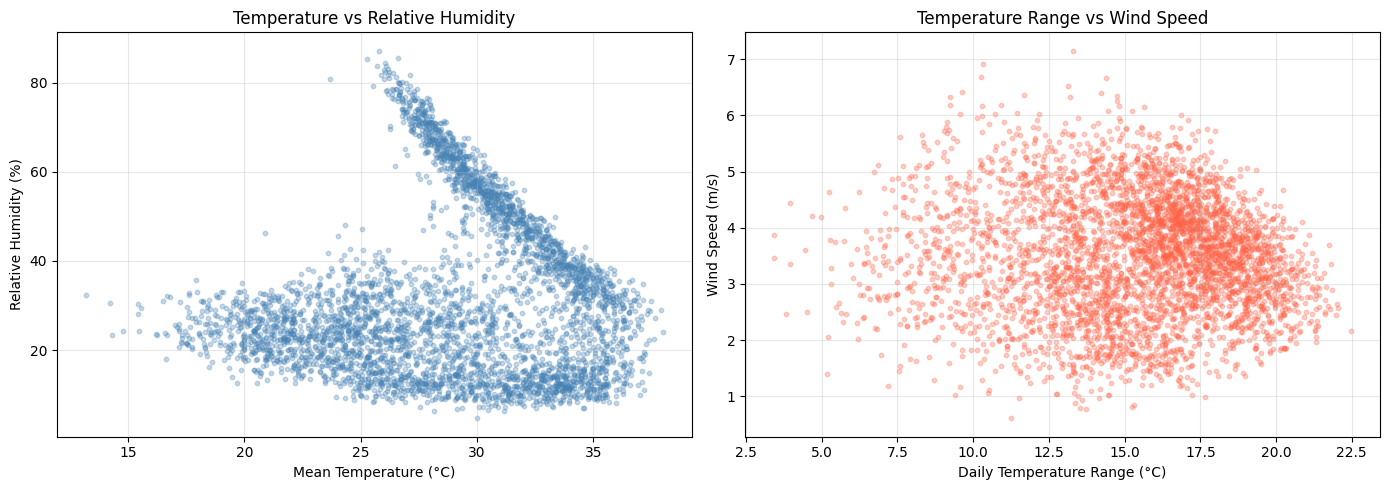

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="steelblue", s=10)
axes[0].set_title("Temperature vs Relative Humidity")
axes[0].set_xlabel("Mean Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="tomato", s=10)
axes[1].set_title("Temperature Range vs Wind Speed")
axes[1].set_xlabel("Daily Temperature Range (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
Sudan shows a much stronger negative relationship between temperature 
and humidity than Ethiopia or Kenya. At extreme temperatures above 
35°C humidity drops very low confirming desert conditions.

Plot 2 - Temperature Range vs Wind Speed:
Sudan shows wider daily temperature ranges than East African countries.
Desert environments heat up quickly during the day and cool rapidly 
at night creating large temperature swings.

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
Sudan shows a much stronger negative relationship between temperature 
and humidity than Ethiopia or Kenya. At extreme temperatures above 
35°C humidity drops very low confirming desert conditions.

Plot 2 - Temperature Range vs Wind Speed:
Sudan shows wider daily temperature ranges than East African countries.
Desert environments heat up quickly during the day and cool rapidly 
at night creating large temperature swings.

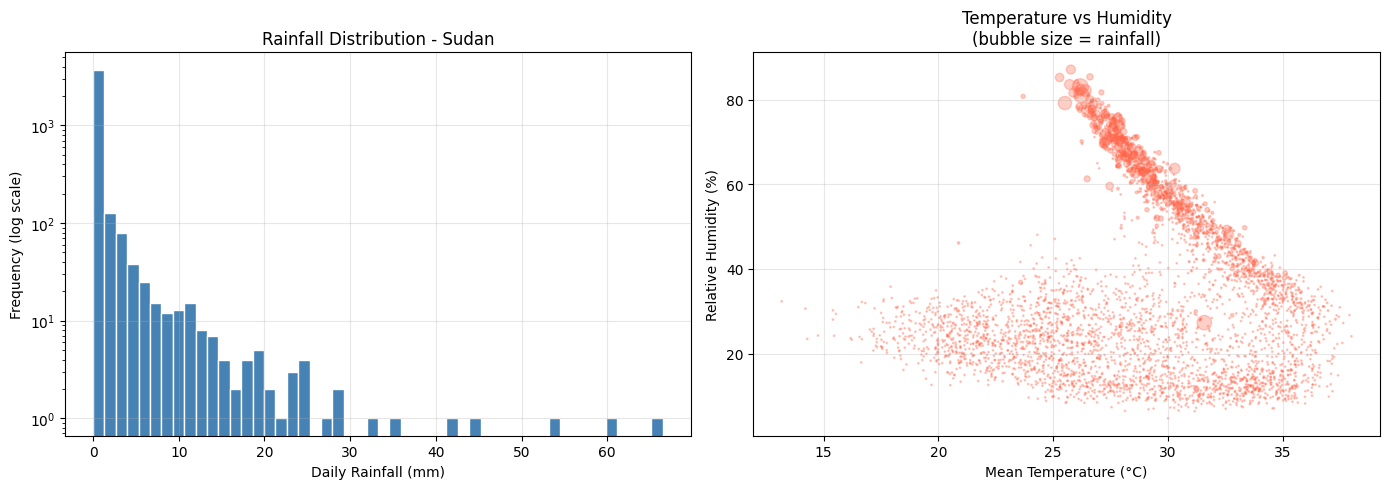

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["PRECTOTCORR"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Rainfall Distribution - Sudan")
axes[0].set_xlabel("Daily Rainfall (mm)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"] * 2 + 1, alpha=0.3, color="tomato")
axes[1].set_title("Temperature vs Humidity\n(bubble size = rainfall)")
axes[1].set_xlabel("Mean Temperature (°C)")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Insights - Sudan

1. Sudan is the hottest country analyzed with mean temperature 28.76°C
2. Extremely arid with average daily rainfall of only 0.64mm
3. Very short rainy season of only 2-3 months per year
4. Strong negative correlation between temperature and humidity 
   confirms severe desert conditions
5. Rising temperatures in Sudan pose an existential threat to 
   communities already living at the edge of survivable conditions